
# Light Field Microscope

> **Primary physics reference:** M. Broxton, L. Grosenick, S. Yang, N. Cohen, A. Andalman, K. Deisseroth, M. Levoy, *Wave optics theory and 3-D deconvolution for the light field microscope*, Optics Express 21(21):25418, 2013.

> **Implementation lineage reference:** `reference_website_github.md`, which points to the OLAF / pyolaf wave-optics light-field code family used as the external implementation reference for this cleaned task.

This notebook reviews the cleaned benchmark as a **volume reconstruction** problem. The main benchmark uses planar targets only as a convenient special case: each observation is still modeled as a 3D inverse problem, but the reconstruction depth grid has length `1`. The notebook also includes a separate five-slice demonstration that reconstructs a volume on `[-100, -75, -50, -25, 0]` `um` for a target placed at `-50` `um`.



## 1. Problem Setup

The measurement model is a Poisson imaging system:

$$
\mathbf{m} \sim \mathrm{Poisson}(A\mathbf{v}),
$$

where $\mathbf{m}$ is the sensor pixel-count vector, $\mathbf{v}$ is the stacked 3D fluorescence volume, and $A$ is the system matrix. Each column of $A$ is built by simulating one fluorescent source voxel through the wave-optics model, so $a_{ji} \propto |U_{\mathrm{sens}}(\mathbf{x}_j)|^2$ and, after normalization, represents the probability that a photon emitted from voxel $i$ is detected at sensor pixel $j$.

The sensor field $U_{\mathrm{sens}}$ is computed in three steps for each source voxel at axial defocus $\Delta z$.

**Step 1: Debye diffraction integral.** A point source displaced by $\Delta z$ from the native object plane produces a defocused wavefront at the MLA plane. Under the Debye approximation,

$$
U^-_{\mathrm{mla}}(\mathbf{x}) \propto \int_0^\alpha
\sqrt{\cos\theta}(1+\cos\theta)\,
J_0(kr\sin\theta)\,
\exp\!\left(i\frac{u}{2}\frac{\sin^2(\theta/2)}{\sin^2(\alpha/2)}\right)\,
\sin\theta\,d\theta.
$$

Here $k = 2\pi n/\lambda$, $\alpha = \arcsin(\mathrm{NA}/n)$, $r = |\mathbf{x}|/M$, and $u = 4k\Delta z\sin^2(\alpha/2)$. At $\Delta z = 0$ the wavefront is most compact; as $|\Delta z|$ grows it broadens into a defocus ring that illuminates more neighboring lenslets.

**Step 2: MLA transmittance.** The MLA is modeled as a tiled array of thin converging lenses with centers $\mathbf{l}_\ell$, pitch $p_{\mathrm{ml}}$, and focal length $f_m$:

$$
T_{\mathrm{MLA}}(\mathbf{x}) =
\sum_\ell \mathrm{rect}\!\left(\frac{\mathbf{x}-\mathbf{l}_\ell}{p_{\mathrm{ml}}}\right)
\exp\!\left(-\frac{i\pi}{\lambda f_m}|\mathbf{x}-\mathbf{l}_\ell|^2\right).
$$

The post-MLA field is $U^+_{\mathrm{mla}} = U^-_{\mathrm{mla}}\,T_{\mathrm{MLA}}$, so each lenslet clips the incoming wavefront to its aperture and redirects it toward the sensor.

**Step 3: Rayleigh-Sommerfeld propagation.** The post-MLA field propagates a distance $f_m$ to the sensor through the angular-spectrum form of Rayleigh-Sommerfeld propagation:

$$
U_{\mathrm{sens}}(\mathbf{x}) = \mathcal{F}^{-1}\!\left[
\hat{U}_{\mathrm{mla}}^{+}(\mathbf{k}_{\perp})
\exp\!\left(if_m\sqrt{k^2-|\mathbf{k}_{\perp}|^2}\right)
\right](\mathbf{x}).
$$

Here $\hat{U}_{\mathrm{mla}}^{+}$ is the 2D spatial Fourier transform and $\mathbf{k}_{\perp}$ is the transverse wavevector. Evanescent components with $|\mathbf{k}_{\perp}| > k$ are zeroed. The detected intensity pattern $|U_{\mathrm{sens}}(\mathbf{x})|^2$ becomes one sparse column of $A$.

This task is therefore a 3D inverse problem: recover $\mathbf{v}$ from one 2D light-field image. It is ill-posed because the sensor mixes many depth-dependent point-source responses into one multiplexed exposure.

For the planar USAF validation, the object is restricted to a single occupied slice,

$$
v(x, y, z) = x(x, y)\,\delta(z-z_0),
$$

so the benchmark cases are **thickness-1 volumes**, not a different forward model. The five-slice demonstration later in this notebook removes that singleton-depth restriction.


In [1]:

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

TASK_ROOT = Path.cwd().resolve()
if not (TASK_ROOT / 'src').exists():
    TASK_ROOT = next(
        path for path in [TASK_ROOT, *TASK_ROOT.parents]
        if (path / 'src').exists() and (path / 'data').exists()
    )

if str(TASK_ROOT) not in sys.path:
    sys.path.insert(0, str(TASK_ROOT))

from src.visualization import plot_light_field_usaf_comparison, plot_volume_reconstruction_demo

metadata = json.loads((TASK_ROOT / 'data' / 'meta_data.json').read_text(encoding='utf-8'))
raw_data = np.load(TASK_ROOT / 'data' / 'raw_data.npz')
ground_truth = np.load(TASK_ROOT / 'data' / 'ground_truth.npz')
reference_cases = np.load(TASK_ROOT / 'evaluation' / 'reference_outputs' / 'cases.npz')
volume_demo = np.load(TASK_ROOT / 'evaluation' / 'reference_outputs' / 'volume_demo.npz')

with (TASK_ROOT / 'evaluation' / 'reference_outputs' / 'metrics.json').open('r', encoding='utf-8') as handle:
    detailed_metrics = json.load(handle)
with (TASK_ROOT / 'evaluation' / 'reference_outputs' / 'volume_demo_metrics.json').open('r', encoding='utf-8') as handle:
    volume_demo_metrics = json.load(handle)
with (TASK_ROOT / 'evaluation' / 'metrics.json').open('r', encoding='utf-8') as handle:
    boundary_metrics = json.load(handle)

light_field_observations = raw_data['light_field_observations'][0]
benchmark_depth_grids = raw_data['reconstruction_depths_um'][0]
target_volumes = ground_truth['target_volumes'][0]
target_depths_um = ground_truth['target_depths_um'][0]

benchmark_target_images = reference_cases['target_images'][0]
benchmark_observations = reference_cases['light_field_observations'][0]
benchmark_conventional = reference_cases['conventional_images'][0]
benchmark_rl = reference_cases['rl_reconstructions'][0]
profile_x_um = reference_cases['profile_x_um'][0]
profiles_gt = reference_cases['profiles_gt'][0]
profiles_conventional = reference_cases['profiles_conventional'][0]
profiles_rl = reference_cases['profiles_rl'][0]

volume_demo_observation = volume_demo['observation'][0]
volume_demo_depths = volume_demo['depths_um'][0]
volume_demo_target_depth = float(volume_demo['target_depth_um'][0, 0])
volume_demo_gt = np.moveaxis(volume_demo['ground_truth_volume'][0], 0, -1)
volume_demo_rl = np.moveaxis(volume_demo['reconstruction_volume'][0], 0, -1)



## 2. Configuration

The compact cleaned task fixes the microscope parameters and varies only the occupied object depth. The main benchmark uses a `30 x 30` lenslet crop at `15` pixels per lenslet, which gives `450 x 450` sensor images and `450 x 450` reconstruction slices. The generalized demo uses the same lateral sampling but expands the axial grid to five reconstruction depths.


In [ ]:

microscope = metadata['microscope']
mla = metadata['mla']
reconstruction = metadata['reconstruction']
volume_demo_cfg = metadata['volume_demo']

print('Microscope')
print('==========')
for key in ['M', 'NA', 'ftl', 'WaveLength']:
    print(f'{key:>12s}: {microscope[key]}')

print('\nMLA / sampling')
print('===============')
for key in ['lensPitch', 'fm', 'pixelPitch']:
    print(f'{key:>12s}: {mla[key]}')
for key in ['newSpacingPx', 'depthStep']:
    print(f'{key:>12s}: {reconstruction[key]}')

# Solver constants are hardcoded in main.py (not in meta_data.json)
print(' rlIterations: 10  (main.py: _RL_ITERATIONS)')
print(' thetaSamples: 128  (main.py: _THETA_SAMPLES)')
print('   kernelTol: 0.005  (main.py: _KERNEL_TOL)')

print('\nBenchmark interpretation')
print('========================')
for idx, depth_um in enumerate(target_depths_um):
    print(
        f'case {idx}: occupied slice depth = {depth_um:>6.1f} um, '
        f'reconstruction grid = {benchmark_depth_grids[idx].tolist()} um, '
        f'volume shape = {target_volumes[idx].shape}'
    )

print('\nGeneralized volume demo')
print('=======================')
print(f"target depth: {volume_demo_cfg['targetDepthUm']} um")
print(f"reconstruction depths: {volume_demo_depths.tolist()} um")
print(f'volume shape: {volume_demo_gt.shape}')



## 3. Thickness-1 Benchmark Example

The `-70 um` case is the strongest planar-target stress test in the benchmark. The conventional microscope image is badly blurred at this defocus, while the wave-model reconstruction still preserves the line-pair structure because the inversion uses the depth-dependent light-field PSF rather than only a defocused widefield image.


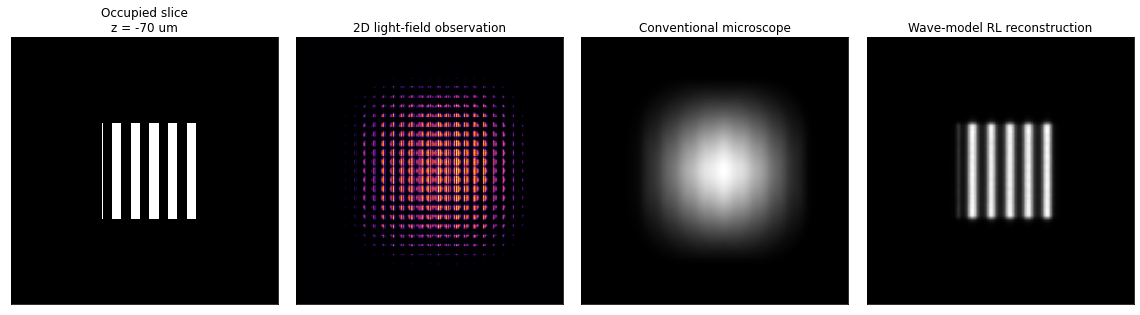

Conventional metrics: {'mse': 0.03928632447884133, 'nrmse': 0.1982077810754192, 'ssim': 0.6193506814752283, 'psnr': 14.057586006925412}
Wave-model RL metrics: {'mse': 0.009890237930290475, 'nrmse': 0.09555994281463713, 'ssim': 0.8663158464060932, 'psnr': 20.394482376286426}


In [3]:

case_idx = int(np.where(target_depths_um == -70)[0][0]) if np.any(target_depths_um == -70) else len(target_depths_um) - 1

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, image, title, cmap in [
    (axes[0], benchmark_target_images[case_idx], f'Occupied slice\nz = {target_depths_um[case_idx]:.0f} um', 'gray'),
    (axes[1], benchmark_observations[case_idx], '2D light-field observation', 'inferno'),
    (axes[2], benchmark_conventional[case_idx], 'Conventional microscope', 'gray'),
    (axes[3], benchmark_rl[case_idx], 'Wave-model RL reconstruction', 'gray'),
]:
    peak = np.max(image)
    disp = image / peak if peak > 0 else image
    ax.imshow(disp, cmap=cmap, vmin=0.0, vmax=1.0, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print('Conventional metrics:', detailed_metrics['cases'][case_idx]['conventional'])
print('Wave-model RL metrics:', detailed_metrics['cases'][case_idx]['rl'])



## 4. All Benchmark Cases

The next figure is assembled with the cleaned plotting helper in `src/visualization.py`. Each row is still a volume-reconstruction problem; the only simplification is that the axial grid contains one occupied slice. This keeps the benchmark close to the planar USAF validation in the paper while preserving the 3D inverse-problem interpretation.


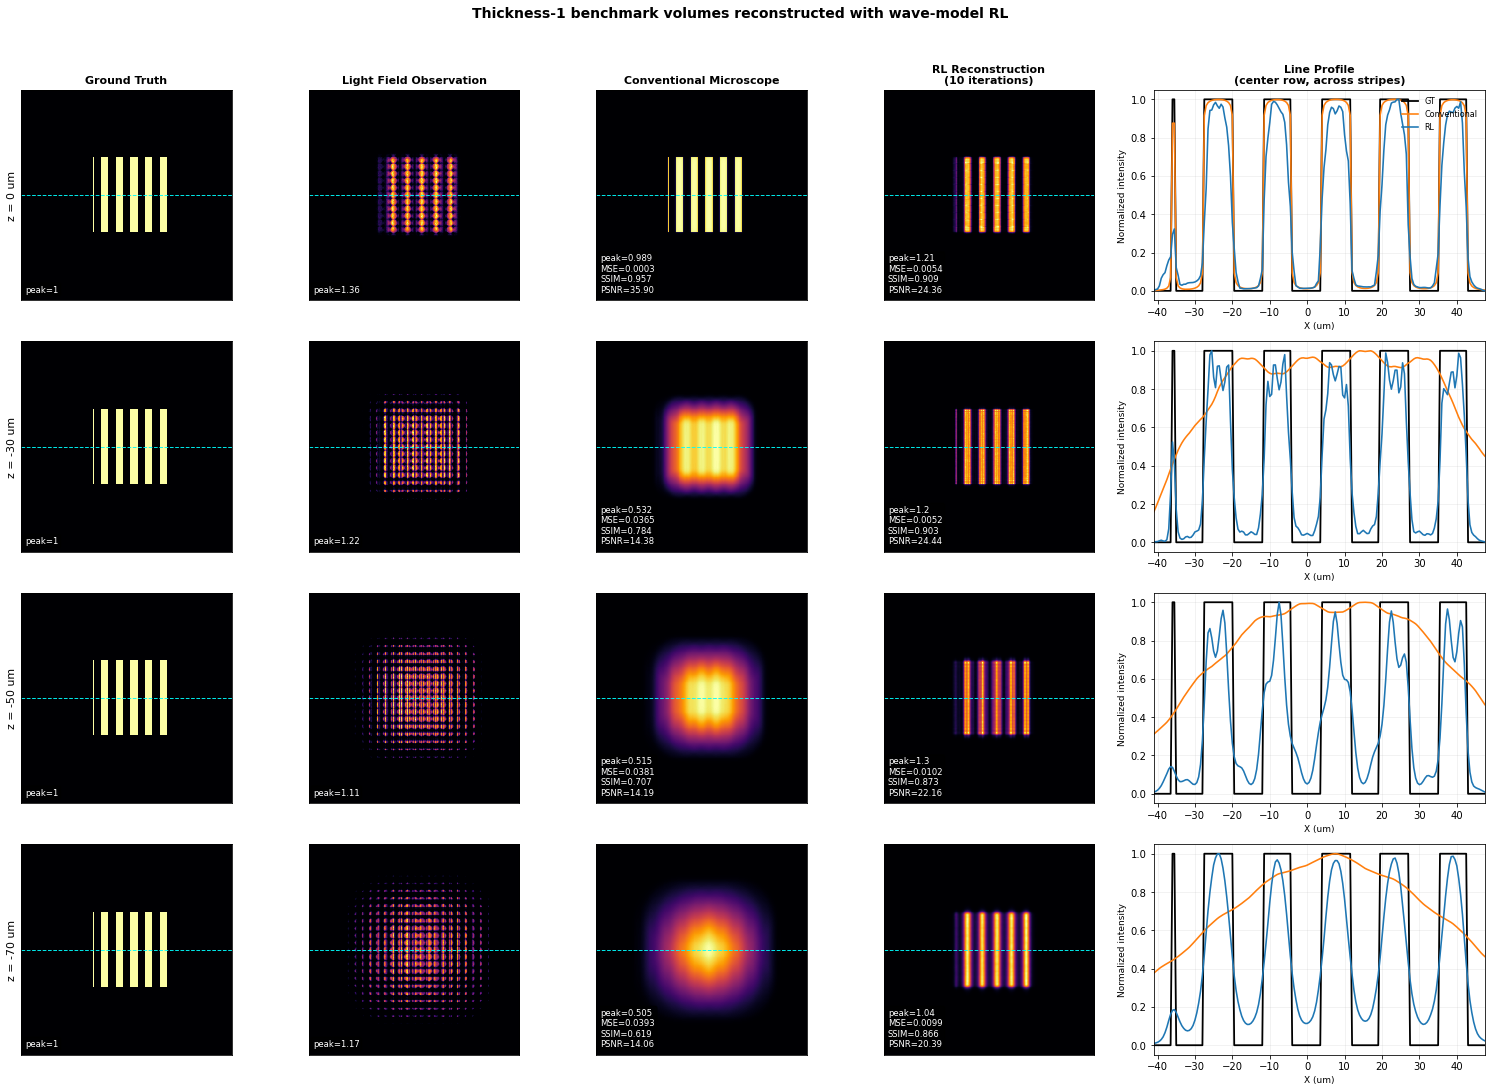

Per-case metrics
z=    0 um | conv nrmse=0.0160, ssim=0.9571 | rl nrmse=0.0605, ssim=0.9095
z=  -30 um | conv nrmse=0.1910, ssim=0.7843 | rl nrmse=0.0600, ssim=0.9031
z=  -50 um | conv nrmse=0.1953, ssim=0.7075 | rl nrmse=0.0780, ssim=0.8728
z=  -70 um | conv nrmse=0.1982, ssim=0.6194 | rl nrmse=0.0956, ssim=0.8663

Evaluation boundary file
{'baseline': [{'method': 'conventional microscope baseline', 'ncc_vs_ref': 0.8021, 'nrmse_vs_ref': 0.098}], 'nrmse_definition': 'sqrt(mean((x - x_ref)^2)) / (max(x_ref) - min(x_ref))', 'ncc_boundary': 0.7219, 'nrmse_boundary': 0.1078}


In [4]:

plot_cases = []
for idx, case_metrics in enumerate(detailed_metrics['cases']):
    plot_cases.append(
        {
            'target_depth_um': float(case_metrics['target_depth_um']),
            'gt_image': benchmark_target_images[idx],
            'observation': benchmark_observations[idx],
            'conventional_image': benchmark_conventional[idx],
            'rl_image': benchmark_rl[idx],
            'conventional': case_metrics['conventional'],
            'rl': case_metrics['rl'],
            'profile': {
                'row': int(benchmark_target_images[idx].shape[0] // 2),
                'x_um': profile_x_um[idx],
                'gt': profiles_gt[idx],
                'conventional': profiles_conventional[idx],
                'rl': profiles_rl[idx],
            },
        }
    )

fig = plot_light_field_usaf_comparison(
    plot_cases,
    rl_iterations=reconstruction['rlIterations'],
    title='Thickness-1 benchmark volumes reconstructed with wave-model RL',
)
plt.show()

print('Per-case metrics')
print('================')
for case_metrics in detailed_metrics['cases']:
    z = case_metrics['target_depth_um']
    conv = case_metrics['conventional']
    rl = case_metrics['rl']
    print(
        f"z={z:>5.0f} um | conv nrmse={conv['nrmse']:.4f}, ssim={conv['ssim']:.4f} | "
        f"rl nrmse={rl['nrmse']:.4f}, ssim={rl['ssim']:.4f}"
    )

print('\nEvaluation boundary file')
print('========================')
print(boundary_metrics)



## 5. Generalized Volume Reconstruction Demo

This is the missing generalization that the benchmark narrative needs. A single planar target is placed at `-50 um`, but the reconstruction is solved on the five-slice depth grid `[-100, -75, -50, -25, 0]` `um`. The expected behavior is that most recovered energy concentrates near the correct slice rather than being spread uniformly across depth.


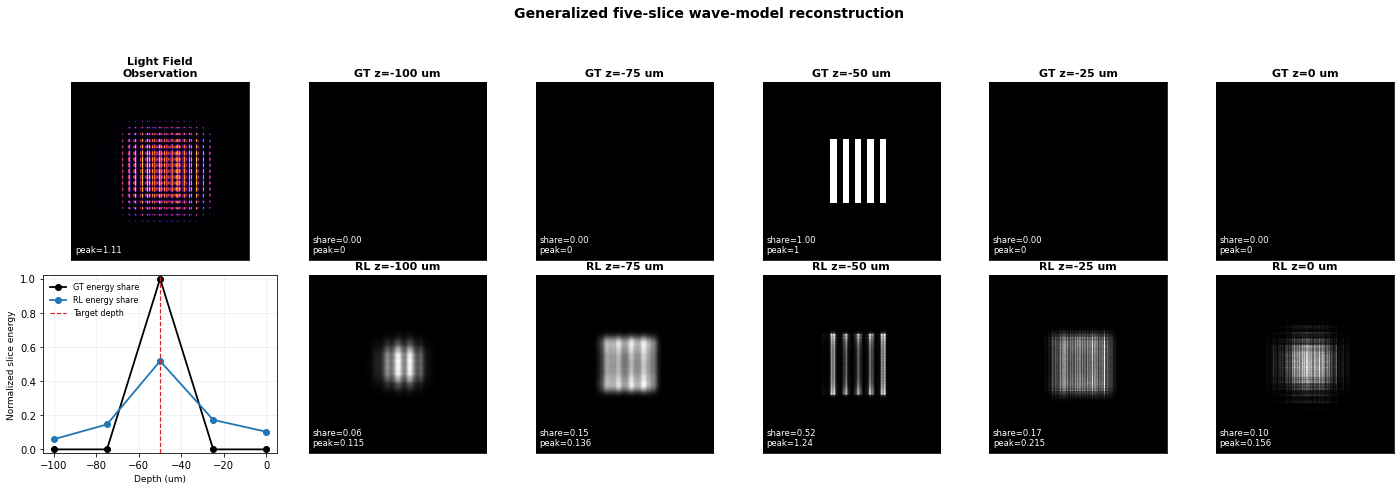

Volume demo metrics
target depth: -50.0 um
reconstructed peak depth: -50.0 um
peak depth error: 0.0 um
target-slice NCC: 0.8616
target-slice NRMSE: 0.1573
off-target energy fraction: 0.4821

Slice-energy shares
  z=-100.0 um -> 0.0595
  z= -75.0 um -> 0.1464
  z= -50.0 um -> 0.5179
  z= -25.0 um -> 0.1728
  z=   0.0 um -> 0.1034


In [5]:

fig = plot_volume_reconstruction_demo(
    observation=volume_demo_observation,
    gt_volume=volume_demo_gt,
    reconstruction_volume=volume_demo_rl,
    depths_um=volume_demo_depths,
    target_depth_um=volume_demo_target_depth,
    title='Generalized five-slice wave-model reconstruction',
)
plt.show()

print('Volume demo metrics')
print('===================')
print(f"target depth: {volume_demo_metrics['target_depth_um']} um")
print(f"reconstructed peak depth: {volume_demo_metrics['reconstructed_peak_depth_um']} um")
print(f"peak depth error: {volume_demo_metrics['peak_depth_error_um']} um")
print(f"target-slice NCC: {volume_demo_metrics['target_slice_ncc']:.4f}")
print(f"target-slice NRMSE: {volume_demo_metrics['target_slice_nrmse']:.4f}")
print(f"off-target energy fraction: {volume_demo_metrics['off_target_energy_fraction']:.4f}")
print('\nSlice-energy shares')
for depth_um, share in zip(volume_demo_metrics['reconstruction_depths_um'], volume_demo_metrics['reconstruction_energy_share']):
    print(f'  z={depth_um:>6.1f} um -> {share:.4f}')



## 6. Reproducing the Task

This notebook only loads saved artifacts, so it runs quickly. To regenerate all benchmark outputs and the five-slice volume demo from scratch, run the cleaned pipeline in `main.py`. The code below is intentionally commented out.


In [6]:

# from pathlib import Path
# import subprocess
# import sys
#
# task_root = TASK_ROOT
# subprocess.run([sys.executable, str(task_root / 'main.py')], check=True)



## 7. Conclusion

This task now makes the same distinction as the Broxton paper. The benchmark cases remain a useful planar-target validation, but they are explicitly treated as **thickness-1 volume reconstructions** rather than as a different 2D problem. The additional five-slice demo shows the more general behavior we actually want from light-field microscopy: reconstruct a volume from one 2D light-field measurement and localize the object in depth through wave-model 3D deconvolution.
